# Retail Demand Forecasting, Inventory & Pricing

**กระบวนการทำงานมาตรฐานของ Data Science**:

> **Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Reporting**

แต่ละหัวข้อจะมีคำอธิบาย**ภาษาไทยแบบเข้าใจง่าย**กำกับไว้ก่อนโค้ดเสมอ บอกว่า **"ทำอะไร" "ทำไมต้องทำ" และ "ทำอย่างไร"**
เพื่อให้อ่านแล้วเข้าใจทั้งกระบวนการ ไม่ใช่แค่รันโค้ดผ่าน

**ข้อมูลที่ใช้**: `data/raw/retail_store_inventory.csv` — ยอดขายรายวันของร้านค้าปลีก 5 ร้าน x สินค้า 20 ชนิด
ตลอด 731 วัน (2022-01-01 ถึง 2024-01-01) รวม 73,100 แถว

**โค้ดที่ใช้ซ้ำ**: ฟังก์ชันหลักทั้งหมด (cleaning, feature engineering, split, SARIMA, LSTM, inventory policy,
elasticity, metrics) อยู่ในแพ็กเกจ `src/` อยู่แล้ว (เขียนแยกไว้เป็นโมดูลที่ทดสอบด้วย pytest) โน้ตบุ๊กนี้แค่
**เรียกใช้**ฟังก์ชันเหล่านั้นตามลำดับ ไม่ได้เขียนโค้ดใหม่ซ้ำซ้อน — เป็นแนวทางที่ดีของ data science จริง:
แยก "โค้ดที่ใช้ซ้ำได้" ออกจาก "การเล่าเรื่อง/วิเคราะห์"


---
# Problem Statement (โจทย์และจุดประสงค์ของโปรเจกต์)

ร้านค้าปลีกที่ขายสินค้าหลายชนิดในหลายสาขา ต้องตัดสินใจ 3 เรื่องที่เชื่อมโยงกันทุกวัน ต่อทุกคู่ (ร้าน, สินค้า):
**จะขายได้เท่าไหร่ ควรสต็อกเท่าไหร่ และควรตั้งราคาเท่าไหร่** ถ้าตัดสินใจผิดข้อใดข้อหนึ่ง จะมีต้นทุนที่จับต้องได้ทันที:
- ทายยอดขายต่ำไป → ของหมด เสียโอกาสขาย (lost sales)
- สต็อกไว้เยอะเกินจำเป็น → เงินทุนจมอยู่กับสินค้าที่ยังขายไม่ออก (holding cost)
- ตั้งราคาไม่เหมาะสม → เสียรายได้ที่ควรจะได้ไปฟรีๆ

โปรเจกต์นี้ใช้ข้อมูลยอดขายร้านค้าปลีกชุดเดียว มาตอบ 3 คำถามหลัก โดยแต่ละข้อต่อยอดจากข้อก่อนหน้า:

1. **โมเดล deep learning (LSTM) พยากรณ์ยอดขายรายวันได้แม่นกว่าโมเดลสถิติคลาสสิก (SARIMA) จริงหรือไม่?**
   ต้องวัดผลบนช่วงเวลาเดียวกัน ด้วยตัวชี้วัดเดียวกัน เพื่อให้การเปรียบเทียบเป็นธรรม ไม่ใช่แค่เดาเอา
2. **เมื่อมีผลพยากรณ์ (พร้อมความไม่แน่นอนของมัน) แล้ว ควรตั้งจุดสั่งซื้อ/ปริมาณสั่งซื้อเท่าไหร่**
   เพื่อลดโอกาสของหมด โดยไม่ทำให้สต็อกล้นเกินจำเป็น?
3. **เมื่อรู้ว่ายอดขายตอบสนองต่อราคา ส่วนลด และราคาคู่แข่งอย่างไร ควรแนะนำราคาเท่าไหร่**
   เพื่อเพิ่มรายได้สูงสุด แทนที่จะตั้งราคาจากความรู้สึก?

**หมายเหตุ**: คอลัมน์ `Demand Forecast` ที่มากับข้อมูล คือตัวแทนของ "สิ่งที่วิธีเดิม/วิธีง่ายๆ ทำได้อยู่แล้ว"
มันถูกใส่มาให้เป็นมาตรฐานเปรียบเทียบที่ต้องพยายามเอาชนะ ไม่ใช่ทางลัดให้หยิบไปใช้ตรงๆ (ดูรายละเอียดเพิ่มเติมใน Stage 1 ด้านล่าง)


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

# ใช้ฟอนต์ที่รองรับภาษาไทย (ฟอนต์ default ของ matplotlib แสดงข้อความไทยในกราฟไม่ได้)
plt.rcParams["font.family"] = "Tahoma"
plt.rcParams["axes.unicode_minus"] = False

from src import config

print("โปรเจกต์อยู่ที่:", config.ROOT)
print("N_SERIES_SUBSET =", config.N_SERIES_SUBSET, "(ยังทำงานกับข้อมูลบางส่วนก่อน ค่อยขยายเป็นทั้งหมดทีหลัง)")


โปรเจกต์อยู่ที่: /Users/athens/Downloads/Coding/Retail Store Inventory
N_SERIES_SUBSET = 10 (ยังทำงานกับข้อมูลบางส่วนก่อน ค่อยขยายเป็นทั้งหมดทีหลัง)


---
# Stage 1 — Business Understanding (เข้าใจโจทย์ธุรกิจ)

### ทำอะไร
แปลงโจทย์ธุรกิจที่เป็นภาษาคนธรรมดา ให้กลายเป็นปัญหาที่วัดผลได้ด้วยตัวเลข **ก่อน**ที่จะแตะข้อมูลจริง

### ทำไมต้องทำก่อน
ถ้าไม่กำหนด "ตัวชี้วัดความสำเร็จ" ไว้ตั้งแต่แรก จะไม่มีทางรู้เลยว่าโมเดลที่สร้างขึ้นมาดีพอหรือยัง
เพราะ "ดี" เป็นคำที่คลุมเครือ ต้องแปลงให้เป็นตัวเลขที่เถียงกันไม่ได้

### โจทย์ทั้ง 3 ข้อของโปรเจกต์นี้

| Challenge | โจทย์ | ตัวแปรเป้าหมาย (target) | ตัวชี้วัดความสำเร็จ |
|---|---|---|---|
| 1. Demand Forecasting | พยากรณ์ `Units Sold` รายวัน ต่อ 1 คู่ (ร้าน, สินค้า) | `Units Sold` | ต้องแม่นกว่า SARIMA/seasonal-naive วัดด้วยค่า MASE |
| 2. Inventory Optimization | หาจุดสั่งซื้อ/ปริมาณสั่งซื้อ จากผลพยากรณ์ของข้อ 1 | stockout rate, holding cost | stockout rate หรือต้นทุนรวมต้องต่ำกว่าพฤติกรรมสั่งซื้อเดิม |
| 3. Dynamic Pricing | แนะนำราคาที่เพิ่มรายได้สูงสุด | คำแนะนำราคา | revenue เพิ่มขึ้นเทียบราคาเฉลี่ยเดิม |

**หมายเหตุสำคัญ**: คอลัมน์ `Demand Forecast` ที่มีอยู่แล้วในไฟล์ CSV จะถูกใช้เป็น**มาตรฐานเปรียบเทียบ (benchmark) ที่ต้องเอาชนะเท่านั้น**
ห้ามนำไปใช้เป็น feature หรือ target เด็ดขาด เพราะจะเท่ากับ "แอบดูคำตอบของคนอื่น" ก่อนพยากรณ์เอง (data leakage)

โน้ตบุ๊กนี้ครอบคลุมทั้ง 3 challenge: **Demand Forecasting** (Stage 4a) ตามด้วย **Inventory Optimization** (Stage 4b)
และ **Dynamic Pricing** (Stage 4c) ที่ต่อยอดจากผลพยากรณ์และฟีเจอร์ของ Stage 4a


---
# Stage 2a — Data Audit (ตรวจสภาพข้อมูล)

### ทำอะไร
ตรวจ "สุขภาพ" ของข้อมูลก่อนใช้งาน เหมือนตรวจสภาพรถมือสองก่อนซื้อ — ดูว่าข้อมูลครบไหม มีค่าผิดปกติไหม
ชนิดข้อมูล (dtype) ถูกต้องหรือยัง

### ทำไมต้องทำ
ถ้าข้อมูลมีปัญหา (วันที่ขาดหาย ค่าติดลบผิดปกติ ฯลฯ) แล้วไม่รู้ตัว โมเดลที่สร้างจากข้อมูลนั้นจะผิดเพี้ยนไปด้วย
โดยที่เราจะไม่รู้ตัวจนกว่าจะเอาไปใช้งานจริงแล้วพัง


In [2]:
raw = pd.read_csv(config.DATA_RAW, parse_dates=[config.DATE_COL])
print("จำนวนแถว x คอลัมน์:", raw.shape)
raw.head()


จำนวนแถว x คอลัมน์: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [3]:
raw.dtypes


Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition             object
Holiday/Promotion              int64
Competitor Pricing           float64
Seasonality                   object
dtype: object

### ตรวจว่าข้อมูลครบทุกวันหรือไม่ (panel completeness)

ข้อมูลนี้เป็น "panel data" คือมี 5 ร้าน x 20 สินค้า = 100 คู่ และแต่ละคู่ควรมีข้อมูลครบทุกวันตลอด 731 วัน
ถ้าขาดหายไปบางวันจะเป็นปัญหาใหญ่มากตอนทำ time series (สร้างช่องว่างที่โมเดลตีความผิดได้)

In [4]:
n_dates = raw[config.DATE_COL].nunique()
n_series = raw.groupby(config.ID_COLS).ngroups
expected_rows = n_dates * n_series
print(f"จำนวนวันที่ไม่ซ้ำ: {n_dates}, จำนวนคู่ร้าน-สินค้า: {n_series}, แถวที่ควรมี: {expected_rows}, แถวจริง: {len(raw)}")
assert expected_rows == len(raw), "ข้อมูลไม่ครบ ต้องตรวจสอบเพิ่มเติม"

dup = raw.duplicated(subset=config.ID_COLS + [config.DATE_COL]).sum()
print("จำนวนแถวที่ซ้ำกัน (ร้าน, สินค้า, วันที่ เดียวกัน):", dup)
assert dup == 0
print("สรุป: ข้อมูลครบ 100% ไม่มีวันไหนขาด ไม่มีแถวซ้ำ")


จำนวนวันที่ไม่ซ้ำ: 731, จำนวนคู่ร้าน-สินค้า: 100, แถวที่ควรมี: 73100, แถวจริง: 73100
จำนวนแถวที่ซ้ำกัน (ร้าน, สินค้า, วันที่ เดียวกัน): 0
สรุป: ข้อมูลครบ 100% ไม่มีวันไหนขาด ไม่มีแถวซ้ำ


### ตรวจค่าว่าง (missing values) และค่าที่สมเหตุสมผล (range check)

ตรวจว่ามีช่องไหนเป็นค่าว่างบ้าง และค่าต่างๆ อยู่ในช่วงที่สมเหตุสมผลไหม เช่น สินค้าคงคลังต้องไม่ติดลบ
ส่วนลดต้องอยู่ระหว่าง 0-100% ราคาต้องเป็นบวก

In [5]:
print("จำนวนค่าว่างต่อคอลัมน์:")
print(raw.isna().sum())

checks = {
    "Inventory Level >= 0": (raw["Inventory Level"] >= 0).all(),
    "Units Sold >= 0": (raw["Units Sold"] >= 0).all(),
    "Units Ordered >= 0": (raw["Units Ordered"] >= 0).all(),
    "Discount in [0,100]": raw["Discount"].between(0, 100).all(),
    "Price > 0": (raw["Price"] > 0).all(),
    "Competitor Pricing > 0": (raw["Competitor Pricing"] > 0).all(),
    "Holiday/Promotion เป็น binary": set(raw["Holiday/Promotion"].unique()) <= {0, 1},
}
for k, v in checks.items():
    print(f"{'ผ่าน ' if v else 'ไม่ผ่าน'} - {k}")


จำนวนค่าว่างต่อคอลัมน์:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64
ผ่าน  - Inventory Level >= 0
ผ่าน  - Units Sold >= 0
ผ่าน  - Units Ordered >= 0
ผ่าน  - Discount in [0,100]
ผ่าน  - Price > 0
ผ่าน  - Competitor Pricing > 0
ผ่าน  - Holiday/Promotion เป็น binary


### ทำความสะอาดข้อมูล (cleaning) แล้วบันทึกไว้ใช้ซ้ำ

แปลงชนิดข้อมูลให้ถูกต้อง (เช่น Store ID ควรเป็น category ไม่ใช่ข้อความธรรมดา, Date เป็น datetime จริง)
ผ่านฟังก์ชัน `clean_panel()` ที่เขียนแยกไว้ใน `src/data/clean.py` (มีเทสยืนยันความถูกต้องแล้ว) เพื่อไม่ให้ต้องเขียนโค้ดซ้ำ
ทุกครั้งที่ใช้ข้อมูล แล้วบันทึกผลลัพธ์เป็นไฟล์ parquet (โหลดเร็วกว่า CSV มาก) ไว้ใช้ในขั้นตอนถัดไป

In [6]:
from src.data.clean import clean_panel

cleaned = clean_panel(raw)
config.DATA_INTERIM.parent.mkdir(parents=True, exist_ok=True)
cleaned.to_parquet(config.DATA_INTERIM, index=False)
print("บันทึกแล้ว:", config.DATA_INTERIM, cleaned.shape)
cleaned.dtypes


บันทึกแล้ว: /Users/athens/Downloads/Coding/Retail Store Inventory/data/interim/cleaned_panel.parquet (73100, 15)


Date                  datetime64[ns]
Store ID                    category
Product ID                  category
Category                    category
Region                      category
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Demand Forecast              float64
Price                        float64
Discount                       int64
Weather Condition           category
Holiday/Promotion               int8
Competitor Pricing           float64
Seasonality                 category
dtype: object

---
# Stage 2b — Exploratory Data Analysis / EDA (วิเคราะห์เชิงลึก)

### ทำอะไร
"คุยกับข้อมูล" เพื่อหา pattern ที่ซ่อนอยู่ ก่อนไปสร้างฟีเจอร์และโมเดล

### ทำไมต้องทำ
Pattern ที่เจอในขั้นนี้จะเป็นตัวกำหนดว่าควรสร้างฟีเจอร์อะไรใน Stage 3 เช่น ถ้าเจอว่ายอดขายมี pattern
รายสัปดาห์ชัดเจน ก็ควรสร้างฟีเจอร์ "วันในสัปดาห์" ให้โมเดล

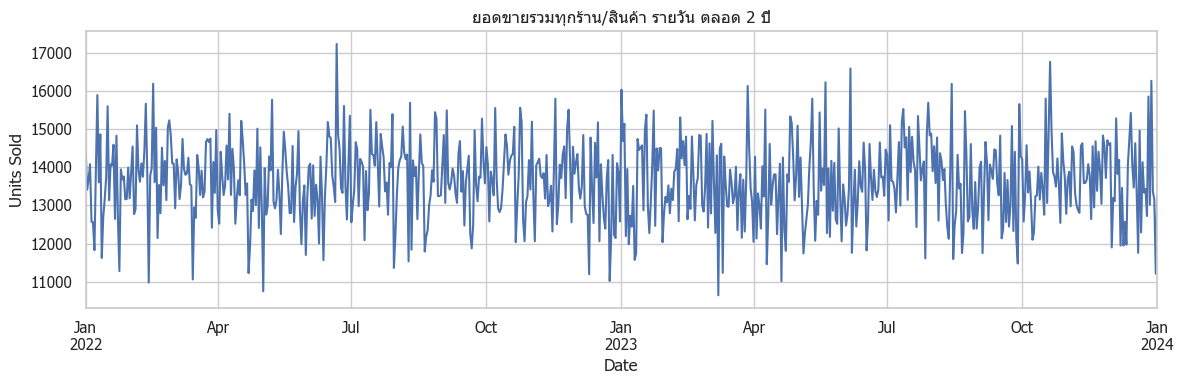

In [7]:
import seaborn as sns
sns.set_theme(style="whitegrid", rc={"font.family": "Tahoma"})

daily_total = cleaned.groupby(config.DATE_COL)["Units Sold"].sum()

fig, ax = plt.subplots(figsize=(12, 4))
daily_total.plot(ax=ax)
ax.set_title("ยอดขายรวมทุกร้าน/สินค้า รายวัน ตลอด 2 ปี")
ax.set_ylabel("Units Sold")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_daily_total_units_sold.png", dpi=120)
plt.show()


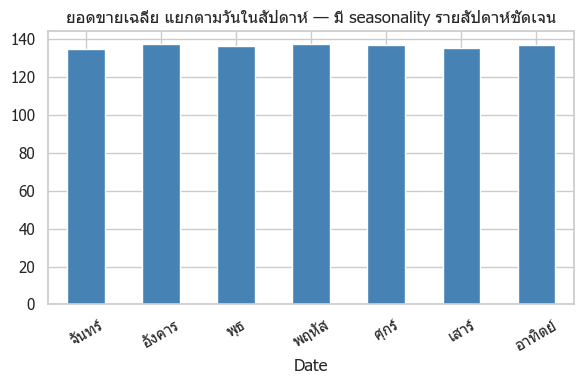

In [8]:
dow_avg = cleaned.groupby(cleaned[config.DATE_COL].dt.dayofweek)["Units Sold"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
dow_avg.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xticklabels(["จันทร์","อังคาร","พุธ","พฤหัส","ศุกร์","เสาร์","อาทิตย์"], rotation=30)
ax.set_title("ยอดขายเฉลี่ย แยกตามวันในสัปดาห์ — มี seasonality รายสัปดาห์ชัดเจน")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_dow_avg_units_sold.png", dpi=120)
plt.show()


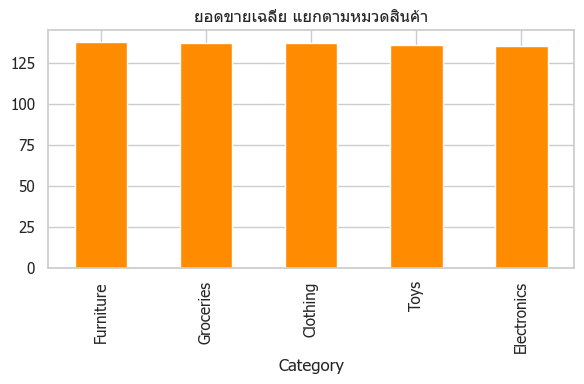

In [9]:
cat_avg = cleaned.groupby("Category", observed=True)["Units Sold"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
cat_avg.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("ยอดขายเฉลี่ย แยกตามหมวดสินค้า")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_category_avg_units_sold.png", dpi=120)
plt.show()


### เทียบ `Demand Forecast` (ที่มากับไฟล์) กับยอดขายจริง

ต้องเข้าใจว่าคอลัมน์นี้คือ "มาตรฐานเดิม" ที่ต้องเอาชนะ — ไม่ใช่คำตอบที่ถูกต้อง

In [10]:
corr = cleaned[["Units Sold", "Demand Forecast"]].corr().iloc[0, 1]
err = cleaned["Demand Forecast"] - cleaned["Units Sold"]
print(f"ความสัมพันธ์ (correlation) ระหว่าง Units Sold กับ Demand Forecast = {corr:.3f}")
print(f"คลาดเคลื่อนเฉลี่ย (MAE) ของ Demand Forecast เดิม = {err.abs().mean():.2f} หน่วย")


ความสัมพันธ์ (correlation) ระหว่าง Units Sold กับ Demand Forecast = 0.997
คลาดเคลื่อนเฉลี่ย (MAE) ของ Demand Forecast เดิม = 8.34 หน่วย


### ตรวจว่ายอดขายถูก "บีบ" จากสต็อกหมดหรือไม่ (demand censoring)

จุดสำคัญที่มือใหม่มักมองข้าม: ถ้าสินค้าหมดสต็อก ยอดขายที่บันทึกไว้จะต่ำกว่าความต้องการซื้อจริง
เพราะขายได้แค่เท่าที่มีของ ต้องตรวจสอบไว้เป็นข้อควรระวังก่อนไปแปลผลโมเดลพยากรณ์

In [11]:
near_stockout = (cleaned["Units Sold"] >= 0.95 * cleaned["Inventory Level"]) & (cleaned["Inventory Level"] > 0)
print(f"สัดส่วนแถวที่ยอดขายใกล้เคียงสต็อกคงเหลือ (สัญญาณสต็อกหมด): {near_stockout.mean()*100:.2f}%")
print("-> เก็บไว้เป็นข้อควรระวัง: yodขายที่บันทึกอาจต่ำกว่าความต้องการซื้อจริงในบางวัน")


สัดส่วนแถวที่ยอดขายใกล้เคียงสต็อกคงเหลือ (สัญญาณสต็อกหมด): 5.13%
-> เก็บไว้เป็นข้อควรระวัง: yodขายที่บันทึกอาจต่ำกว่าความต้องการซื้อจริงในบางวัน


### พฤติกรรมด้านราคา — ใช้เตรียมฟีเจอร์สำหรับ Challenge 3 (Pricing) ในอนาคต

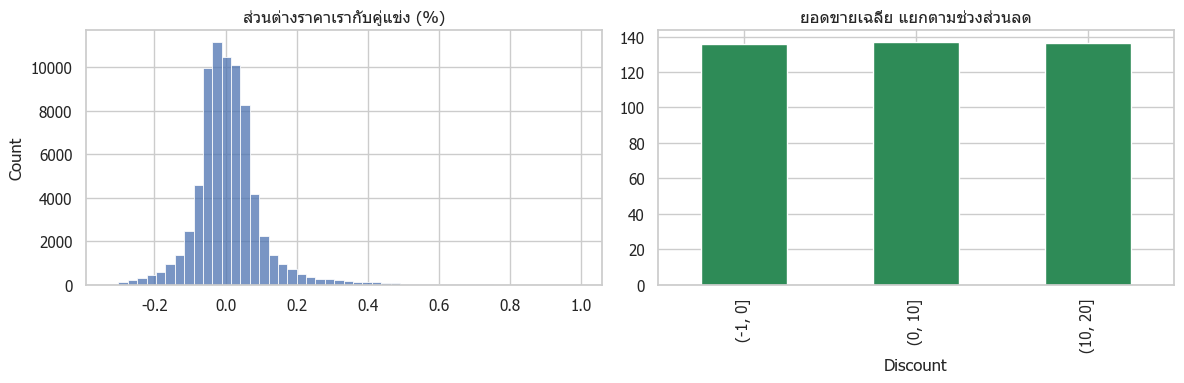

In [12]:
price_gap_pct = (cleaned["Price"] - cleaned["Competitor Pricing"]) / cleaned["Competitor Pricing"]
discount_bins = pd.cut(cleaned["Discount"], bins=[-1, 0, 10, 20, 30, 100])
discount_effect = cleaned.groupby(discount_bins, observed=True)["Units Sold"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(price_gap_pct, bins=50, ax=axes[0])
axes[0].set_title("ส่วนต่างราคาเรากับคู่แข่ง (%)")
discount_effect.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("ยอดขายเฉลี่ย แยกตามช่วงส่วนลด")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "eda_price_gap_pct.png", dpi=120)
plt.show()


### สรุป Stage 2 (EDA)

- ยอดขายมี **seasonality รายสัปดาห์**ชัดเจน → ต้องสร้างฟีเจอร์วันในสัปดาห์
- คอลัมน์ `Demand Forecast` เดิม มี error พอสมควร → เป็น benchmark ที่พอเอาชนะได้ ไม่ใช่คำตอบสมบูรณ์แบบ
- มีสัญญาณของ **demand censoring** (สต็อกหมดบีบยอดขาย) → เป็นข้อจำกัดของข้อมูลที่ต้องจำไว้ตอนแปลผล
- ส่วนลดและช่องว่างราคากับคู่แข่งมีความสัมพันธ์กับยอดขาย → เก็บไว้ใช้ตอนทำ Challenge 3


---
# Stage 3 — Data Preparation (เตรียมข้อมูลสำหรับโมเดล)

### ทำอะไร
แปลง "ข้อมูลดิบ" ให้กลายเป็น "ฟีเจอร์" ที่โมเดลนำไปใช้เรียนรู้ได้ แล้วแบ่งข้อมูลเป็นชุด train/validation/test
อย่างถูกวิธี

### ทำไมต้องทำ
โมเดลไม่สามารถเข้าใจข้อมูลดิบได้ดีเท่าที่มนุษย์ช่วยแปลงให้ — และถ้าแบ่งข้อมูลผิดวิธี (เช่น สุ่มแบ่งแบบ time series ทั่วไป)
จะเกิด **data leakage** ทำให้ผลลัพธ์ดูดีเกินจริงตอนพัฒนา แต่ใช้งานจริงไม่ได้ผล

### ฟีเจอร์ที่สร้าง (ใน `src/data/features.py`)
- **Calendar features**: วันในสัปดาห์ เดือน สัปดาห์ที่เท่าไหร่ของปี (+ แปลงเป็น sin/cos ให้โมเดลเข้าใจว่าเสาร์-อาทิตย์อยู่ติดกัน)
- **Lag features**: ยอดขายเมื่อ 1, 7, 14, 28 วันก่อน
- **Rolling features**: ค่าเฉลี่ย/ส่วนเบี่ยงเบนของยอดขายใน 7/14/28 วันที่ผ่านมา (คำนวณโดย **shift ไป 1 วันก่อนเสมอ**
  เพื่อไม่ให้ค่าของวันนี้หลุดเข้าไปอยู่ในค่าเฉลี่ยของตัวเอง — จุดสำคัญที่ป้องกัน data leakage)
- **Price features**: ส่วนต่างราคากับคู่แข่ง ราคาที่แท้จริงหลังหักส่วนลด
- **Inventory features**: สต็อกคงเหลือพอขายได้กี่วัน, ธงสัญญาณสต็อกหมด
- **One-hot encoding**: แปลง Category/Region/Weather/Seasonality เป็นคอลัมน์ตัวเลข 0/1

**ไม่ใช้** `Demand Forecast` เป็นฟีเจอร์เด็ดขาด (ตามที่กำหนดไว้ใน Stage 1)


In [13]:
from src.data.features import build_features_full

features = build_features_full()
print("รูปร่างข้อมูลหลังสร้างฟีเจอร์:", features.shape, f"(จากเดิม {cleaned.shape[1]} คอลัมน์ กลายเป็น {features.shape[1]} คอลัมน์)")
features.head()


รูปร่างข้อมูลหลังสร้างฟีเจอร์: (7310, 55) (จากเดิม 15 คอลัมน์ กลายเป็น 55 คอลัมน์)


,Date,Store ID,Product ID,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing,day_of_week,is_weekend,month,week_of_year,day_of_year,dow_sin,dow_cos,month_sin,month_cos,units_sold_lag_1,units_sold_lag_7,units_sold_lag_14,units_sold_lag_28,units_sold_roll_mean_7,units_sold_roll_std_7,units_sold_roll_mean_14,units_sold_roll_std_14,units_sold_roll_mean_28,units_sold_roll_std_28,inventory_roll_mean_7,discount_roll_mean_7,price_gap,price_gap_pct,discount_pct,effective_price,days_of_supply,stockout_flag,Category_Clothing,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys,Region_East,Region_North,Region_South,Region_West,Weather Condition_Cloudy,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Autumn,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,S002,P0001,343,104,144,112.55,32.80,20,1,30.78,5,1,1,52,1,-0.974928,-0.222521,0.5,0.866025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.02,0.065627,0.20,26.2400,NaN,0,False,False,False,True,False,False,False,True,False,False,False,False,True,False,True,False,False
1,2022-01-02,S002,P0001,402,343,141,339.04,66.57,20,1,63.92,6,1,1,52,2,-0.781831,0.623490,0.5,0.866025,104.0,NaN,NaN,NaN,104.0,NaN,104.0,NaN,104.0,NaN,343.000000,20.000000,2.65,0.041458,0.20,53.2560,3.865385,0,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False
2,2022-01-03,S002,P0001,405,96,171,100.82,48.08,0,1,49.40,0,0,1,1,3,0.000000,1.000000,0.5,0.866025,343.0,NaN,NaN,NaN,223.5,168.998521,223.5,168.998521,223.5,168.998521,372.500000,20.000000,-1.32,-0.026721,0.00,48.0800,1.812081,0,False,False,False,False,True,False,True,False,False,False,True,False,False,True,False,False,False
3,2022-01-04,S002,P0001,108,83,25,85.50,45.49,5,1,44.33,1,0,1,1,4,0.781831,0.623490,0.5,0.866025,96.0,NaN,NaN,NaN,181.0,140.353126,181.0,140.353126,181.0,140.353126,383.333333,13.333333,1.16,0.026167,0.05,43.2155,0.596685,0,True,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False
4,2022-01-05,S002,P0001,250,161,70,171.45,56.24,15,1,60.32,2,0,1,1,5,0.974928,-0.222521,0.5,0.866025,83.0,NaN,NaN,NaN,156.5,124.634131,156.5,124.634131,156.5,124.634131,314.500000,11.250000,-4.08,-0.067639,0.15,47.8040,1.597444,0,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False


In [14]:
# ตรวจว่า lag/rolling features มีค่าว่าง (NaN) เฉพาะช่วงต้นของแต่ละ series เท่านั้น (ไม่ใช่ leakage หรือข้อผิดพลาด)
na_counts = features[[c for c in features.columns if "lag" in c or "roll" in c]].isna().sum()
na_counts


units_sold_lag_1            10
units_sold_lag_7            70
units_sold_lag_14          140
units_sold_lag_28          280
units_sold_roll_mean_7      10
units_sold_roll_std_7       20
units_sold_roll_mean_14     10
units_sold_roll_std_14      20
units_sold_roll_mean_28     10
units_sold_roll_std_28      20
inventory_roll_mean_7       10
discount_roll_mean_7        10
stockout_flag                0
dtype: int64

### แบ่งข้อมูล train / validation / test ตามช่วงเวลา

**ห้ามสุ่มแบ่งข้อมูล time series เด็ดขาด** เพราะจะทำให้โมเดล "แอบเห็นอนาคต" ตอนเทรน จึงต้องแบ่งเรียงตามเวลาจริง
ช่วงเวลาเดียวกันนี้จะถูกใช้ซ้ำในทุก Challenge (forecasting, inventory, pricing) เพื่อให้เทียบผลลัพธ์กันได้อย่างยุติธรรม

| ชุดข้อมูล | ช่วงเวลา | ใช้ทำอะไร |
|---|---|---|
| Train | 2022-01-01 ถึง 2023-06-30 | สอนโมเดล |
| Validation | 2023-07-01 ถึง 2023-09-30 | ปรับจูน/หาจุดหยุดเทรน (early stopping) |
| Test | 2023-10-01 ถึง 2024-01-01 | ทดสอบครั้งสุดท้าย ห้ามแตะจนกว่าจะมั่นใจ |


In [15]:
from src.forecasting.splits import time_split

train, val, test = time_split(features)

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5s} จำนวนแถว={len(part):5d}  {part[config.DATE_COL].min().date()} -> {part[config.DATE_COL].max().date()}")

assert len(train) + len(val) + len(test) == len(features)
train_dates, val_dates, test_dates = set(train[config.DATE_COL]), set(val[config.DATE_COL]), set(test[config.DATE_COL])
assert train_dates.isdisjoint(val_dates) and val_dates.isdisjoint(test_dates) and train_dates.isdisjoint(test_dates)
print("ยืนยันแล้ว: ครอบคลุมทุกแถวพอดี และไม่มีวันที่ซ้อนทับกันเลย")

config.DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
train.to_parquet(config.DATA_PROCESSED_DIR / "train.parquet", index=False)
val.to_parquet(config.DATA_PROCESSED_DIR / "val.parquet", index=False)
test.to_parquet(config.DATA_PROCESSED_DIR / "test.parquet", index=False)
print("บันทึก train/val/test.parquet เรียบร้อย")


train จำนวนแถว= 5460  2022-01-01 -> 2023-06-30
val   จำนวนแถว=  920  2023-07-01 -> 2023-09-30
test  จำนวนแถว=  930  2023-10-01 -> 2024-01-01
ยืนยันแล้ว: ครอบคลุมทุกแถวพอดี และไม่มีวันที่ซ้อนทับกันเลย
บันทึก train/val/test.parquet เรียบร้อย


### สรุป Stage 3

ได้ข้อมูลพร้อมใช้งาน: `features_full.parquet` (55 คอลัมน์) + `train/val/test.parquet` ที่แบ่งตามเวลาอย่างถูกวิธี
มีเทสอัตโนมัติ (`tests/test_features.py`, `tests/test_splits.py`) ยืนยันว่าไม่มี data leakage — พร้อมเข้าสู่ Stage 4 (สร้างโมเดล)


---
# Stage 4 — Modeling (สร้างโมเดล)

## Stage 4a — Demand Forecasting: SARIMA vs LSTM

### ทำอะไร
สร้างโมเดลพยากรณ์ยอดขาย (`Units Sold`) ล่วงหน้า 1 วัน เปรียบเทียบ 2 แนวทาง:
- **SARIMA** — โมเดลสถิติคลาสสิก มองยอดขายเป็นสมการทางคณิตศาสตร์ที่อธิบายด้วยค่าในอดีตของตัวมันเอง (autoregressive)
  บวกกับ pattern ฤดูกาล (seasonal) เหมาะกับข้อมูลที่มี pattern ชัดเจนสม่ำเสมอ **ต้องเทรนแยกทีละคู่ร้าน-สินค้า**
- **LSTM** — โครงข่ายประสาทเทียมชนิดหนึ่ง (deep learning) ออกแบบมาสำหรับข้อมูลที่เรียงตามลำดับเวลาโดยเฉพาะ
  จำ pattern ระยะยาวได้ดีกว่าโมเดลสถิติทั่วไป และในโปรเจกต์นี้เทรนเป็น **โมเดลเดียวที่ใช้ร่วมกันทุกคู่ร้าน-สินค้า**
  (global model) ทำให้แต่ละคู่ช่วยกัน "แชร์ความรู้" ระหว่างกันได้ ต่างจาก SARIMA ที่แต่ละคู่เรียนรู้แยกกันเดี่ยวๆ

### ทำไมต้องเปรียบเทียบแบบนี้
เพื่อตอบคำถามจริงของโจทย์: LSTM (ซับซ้อนกว่า ใช้เวลาเทรนนานกว่า) คุ้มค่ากว่าวิธีคลาสสิกที่เรียบง่ายกว่าจริงหรือไม่
ถ้าเปรียบเทียบไม่เป็นธรรม (เช่น ให้โมเดลหนึ่งได้เห็นข้อมูลมากกว่า) ผลสรุปจะเชื่อถือไม่ได้

### กติกาการประเมินผลที่ใช้กับทั้งสองโมเดล (สำคัญมาก เพื่อความยุติธรรม)
ทั้ง SARIMA และ LSTM พยากรณ์แบบ **"1 วันล่วงหน้า โดยใช้ประวัติจริง" (one-step-ahead walk-forward)**:
เดินหน้าไปทีละวันในช่วง test, พยากรณ์ 1 วันถัดไป แล้วก่อนพยากรณ์วันต่อไปจะ "อัปเดต" โมเดลด้วยค่าจริงของวันนั้น
(ไม่ใช่เอาค่าที่ตัวเองพยากรณ์ผิดๆ ไปทบต่อ) ทั้งสองโมเดลจึงได้เห็นข้อมูลในปริมาณ/คุณภาพเดียวกันทุกวัน — เทียบกันได้อย่างเป็นธรรม

### ตัวชี้วัดหลักที่ใช้: MASE (Mean Absolute Scaled Error)
เป็นตัวชี้วัดที่ไม่ขึ้นกับสเกล เหมาะกับการเทียบข้ามสินค้าที่ขายดี/ขายน้อยต่างกันมาก คำนวณโดยเทียบ error ของโมเดล
กับ error ของวิธี "seasonal-naive" (ทายว่าเหมือนสัปดาห์ก่อน) ถ้า **MASE < 1 แปลว่าโมเดลเก่งกว่าการทายแบบไม่ต้องคิดอะไรเลย**


In [16]:
from src.forecasting.evaluate import evaluate_forecasts, compute_scales

# คำนวณ "ค่าอ้างอิง" (scale) ของ MASE จากข้อมูล train เท่านั้น ต่อ 1 คู่ร้าน-สินค้า
# ทุกโมเดลใน notebook นี้จะใช้ scale ชุดเดียวกัน เพื่อให้เทียบผลลัพธ์กันได้อย่างยุติธรรม
scales = compute_scales(train)
pd.Series(scales).describe()


count     10.000000
mean     125.823933
std        5.378641
min      117.100186
25%      123.276902
50%      126.551020
75%      129.403989
max      133.217069
dtype: float64

### Baseline models (มาตรฐานเปรียบเทียบเบื้องต้น)

ก่อนสร้างโมเดลจริง ต้องมี "เส้นฐาน" ไว้เทียบก่อนเสมอ ไม่งั้นจะไม่รู้ว่าโมเดลที่ซับซ้อนขึ้นนั้น "คุ้ม" หรือไม่:
- **Naive**: ทายว่ายอดขายวันนี้ = ยอดขายเมื่อวาน
- **Seasonal-Naive**: ทายว่ายอดขายวันนี้ = ยอดขายเมื่อสัปดาห์ก่อน (จับ pattern รายสัปดาห์ที่เจอใน EDA)
- **Dataset Forecast**: คอลัมน์ `Demand Forecast` เดิมที่มากับไฟล์ (มาตรฐานภายนอกที่ต้องเอาชนะ)

In [17]:
def make_baseline(test_df, pred_col, model_name):
    d = test_df[config.ID_COLS + [config.DATE_COL, config.TARGET_COL, pred_col]].copy()
    d = d.rename(columns={config.TARGET_COL: "y_true", pred_col: "y_pred"})
    d["model"] = model_name
    return d.dropna(subset=["y_pred"])

baseline_naive = make_baseline(test, "units_sold_lag_1", "Naive")
baseline_seasonal_naive = make_baseline(test, "units_sold_lag_7", "SeasonalNaive")
baseline_dataset = make_baseline(test, "Demand Forecast", "DatasetForecast")

baselines = {
    "Naive": baseline_naive,
    "SeasonalNaive": baseline_seasonal_naive,
    "DatasetForecast": baseline_dataset,
}

baseline_summary = pd.DataFrame([
    {"model": name, **evaluate_forecasts(d, scales)["overall"].to_dict()}
    for name, d in baselines.items()
])
baseline_summary


,model,MAE,RMSE,sMAPE,MASE_macro,MASE_volume_weighted
0,Naive,118.233333,151.629624,89.856236,0.940797,0.944370
1,SeasonalNaive,122.484946,154.244322,92.449877,0.977751,0.982678
2,DatasetForecast,8.346806,10.070042,15.532365,0.066431,0.066513


### SARIMA ต่อคู่ร้าน-สินค้า

ใช้ `pmdarima.auto_arima` ค้นหาค่าพารามิเตอร์ (p,d,q)(P,D,Q,7) ที่เหมาะสมที่สุดให้อัตโนมัติต่อ 1 คู่ (ไม่ต้องไล่หาด้วยมือ)
แล้ว walk-forward พยากรณ์ทีละวันตามกติกาด้านบน ทุก run จะถูกบันทึกไว้ใน **MLflow** (เครื่องมือ track การทดลอง)
เพื่อให้ย้อนกลับมาดูผลลัพธ์/เปรียบเทียบได้ทุกเมื่อ

**ขั้นตอนนี้ใช้เวลานานที่สุดในโน้ตบุ๊ก** เพราะต้องค้นหาพารามิเตอร์ + เดินหน้าทีละวันแยกกันทั้ง 10 คู่

In [18]:
from src.forecasting.arima_model import run_arima_all_series

arima_forecasts, arima_orders = run_arima_all_series(train, test, log_to_mlflow=True)
arima_orders


,Store ID,Product ID,order,seasonal_order,MAE,RMSE,MASE
0,S002,P0001,"(0, 0, 0)","(0, 0, 0, 7)",89.001315,108.486612,0.686526
1,S002,P0009,"(3, 0, 3)","(1, 0, 1, 7)",97.453717,118.892400,0.792833
2,S002,P0020,"(0, 0, 1)","(0, 0, 0, 7)",92.453794,112.368014,0.718391
3,S003,P0005,"(0, 0, 0)","(0, 0, 0, 7)",84.407331,98.957426,0.678775
4,S003,P0013,"(0, 0, 0)","(0, 0, 0, 7)",84.569203,101.824204,0.657694
5,S003,P0014,"(0, 0, 0)","(1, 0, 0, 7)",96.455712,119.135412,0.735834
6,S003,P0017,"(0, 0, 0)","(0, 0, 0, 7)",91.805464,115.307935,0.783991
7,S004,P0016,"(0, 0, 0)","(0, 0, 0, 7)",79.735161,95.536239,0.640352
8,S005,P0003,"(0, 0, 0)","(0, 0, 0, 7)",98.848581,121.359280,0.836779
9,S005,P0015,"(0, 0, 0)","(0, 0, 0, 7)",91.547538,108.450228,0.687206


In [19]:
arima_overall = evaluate_forecasts(arima_forecasts, scales)["overall"]
arima_overall


MAE                      90.627781
RMSE                    110.362097
sMAPE                    69.952217
MASE_macro                0.721838
MASE_volume_weighted      0.724424
dtype: float64

### เทียบผลลัพธ์เบื้องต้น: Baseline vs SARIMA

In [20]:
comparison_so_far = pd.concat(
    [baseline_summary, pd.DataFrame([{"model": "SARIMA", **arima_overall.to_dict()}])],
    ignore_index=True,
)
comparison_so_far = comparison_so_far[["model", "MAE", "RMSE", "sMAPE", "MASE_macro", "MASE_volume_weighted"]]
comparison_so_far.sort_values("MASE_macro")


,model,MAE,RMSE,sMAPE,MASE_macro,MASE_volume_weighted
2,DatasetForecast,8.346806,10.070042,15.532365,0.066431,0.066513
3,SARIMA,90.627781,110.362097,69.952217,0.721838,0.724424
0,Naive,118.233333,151.629624,89.856236,0.940797,0.944370
1,SeasonalNaive,122.484946,154.244322,92.449877,0.977751,0.982678


### LSTM (PyTorch) — โมเดล deep learning ตัวเดียวใช้ร่วมกันทุกคู่

**Windowing**: สำหรับวันที่ต้องการพยากรณ์ (วัน t) จะดึงข้อมูลย้อนหลัง 28 วันก่อนหน้า (ไม่รวมวัน t เอง) มาเป็น input
เพื่อไม่ให้มีข้อมูลอนาคตรั่วไหลเข้ามาแม้แต่นิดเดียว

**สถาปัตยกรรม**: LSTM 2 ชั้น (hidden 64 → 32) ต่อด้วย fully-connected layer, ใช้ Adam optimizer,
Huber loss (ทนทานต่อยอดขายที่พุ่งสูงผิดปกติได้ดีกว่า MSE ธรรมดา), หยุดเทรนอัตโนมัติเมื่อผล validation ไม่ดีขึ้น
(early stopping) เพื่อไม่ให้โมเดล overfit

In [21]:
from src.data.load import read_features
from src.forecasting.lstm_model import (
    build_windows, fit_scalers, train_lstm, predict, save_scalers,
)

features_reloaded = read_features()
samples, feat_cols = build_windows(features_reloaded, window=config.LSTM_WINDOW)
print(f"จำนวนฟีเจอร์ต่อวัน = {len(feat_cols)}")
for split, s in samples.items():
    print(f"{split:5s}: {len(s)} หน้าต่างข้อมูล (windows)")


จำนวนฟีเจอร์ต่อวัน = 51
train: 4900 หน้าต่างข้อมูล (windows)
val  : 920 หน้าต่างข้อมูล (windows)
test : 930 หน้าต่างข้อมูล (windows)


In [22]:
# ปรับสเกลข้อมูล (scaling) แยกต่อ 1 คู่ร้าน-สินค้า โดย fit จากชุด train เท่านั้น
scalers = fit_scalers(samples["train"])
print(f"สร้าง scaler สำหรับ {len(scalers)} คู่ร้าน-สินค้า")


สร้าง scaler สำหรับ 10 คู่ร้าน-สินค้า


In [23]:
model, history, run_ctx = train_lstm(
    samples["train"], samples["val"], scalers,
    n_features=len(feat_cols),
    hidden1=64, hidden2=32,
    lr=1e-3, batch_size=64,
    max_epochs=60, patience=8,
    log_to_mlflow=True,
)
print(f"เทรนไปทั้งหมด {len(history['train_loss'])} epoch, best val_loss={min(history['val_loss']):.4f}")


เทรนไปทั้งหมด 9 epoch, best val_loss=0.4186


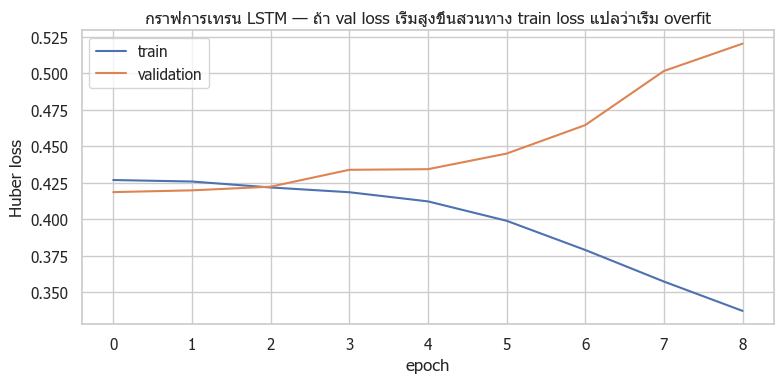

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("Huber loss")
ax.set_title("กราฟการเทรน LSTM — ถ้า val loss เริ่มสูงขึ้นสวนทาง train loss แปลว่าเริ่ม overfit")
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "lstm_training_curve.png", dpi=120)
plt.show()


In [25]:
import mlflow

lstm_forecasts = predict(model, samples["test"], scalers)
lstm_overall = evaluate_forecasts(lstm_forecasts, scales)["overall"]

mlflow.log_metrics({
    "test_MAE": lstm_overall["MAE"],
    "test_RMSE": lstm_overall["RMSE"],
    "test_sMAPE": lstm_overall["sMAPE"],
    "test_MASE_macro": lstm_overall["MASE_macro"],
})
mlflow.end_run()

lstm_overall


MAE                      89.027430
RMSE                    110.331457
sMAPE                    69.604235
MASE_macro                0.709259
MASE_volume_weighted      0.711931
dtype: float64

---
# Stage 5 — Evaluation (ประเมินผลอย่างเป็นทางการ)

### ทำอะไร
รวมผลลัพธ์ของทุกโมเดล (baseline ทั้ง 3 + SARIMA + LSTM) มาเทียบกันในตารางเดียว บนช่วงเวลา test เดียวกัน
ด้วยมาตรวัด (MASE scale) ชุดเดียวกัน แล้วทดสอบว่าความแตกต่างที่เห็น "มีนัยสำคัญทางสถิติจริง" หรือแค่บังเอิญ

In [26]:
config.FORECASTS_DIR.mkdir(parents=True, exist_ok=True)
baselines_all = pd.concat(baselines.values(), ignore_index=True)
baselines_all.to_parquet(config.FORECASTS_DIR / "baseline_forecasts.parquet", index=False)
arima_forecasts.to_parquet(config.FORECASTS_DIR / "arima_forecasts.parquet", index=False)
lstm_forecasts.to_parquet(config.FORECASTS_DIR / "lstm_forecasts.parquet", index=False)

config.ARIMA_DIR.mkdir(parents=True, exist_ok=True)
arima_orders.to_csv(config.ARIMA_DIR / "orders.csv", index=False)
save_scalers(scalers)

all_forecasts = pd.concat([baselines_all, arima_forecasts, lstm_forecasts], ignore_index=True)
all_forecasts["model"].value_counts()


model
Naive              930
SeasonalNaive      930
DatasetForecast    930
SARIMA             930
LSTM               930
Name: count, dtype: int64

In [27]:
rows = []
for model_name, d in all_forecasts.groupby("model"):
    overall = evaluate_forecasts(d, scales)["overall"]
    rows.append({"model": model_name, **overall.to_dict()})

comparison = pd.DataFrame(rows)[["model", "MAE", "RMSE", "sMAPE", "MASE_macro", "MASE_volume_weighted"]]
comparison = comparison.sort_values("MASE_macro").reset_index(drop=True)
comparison


,model,MAE,RMSE,sMAPE,MASE_macro,MASE_volume_weighted
0,DatasetForecast,8.346806,10.070042,15.532365,0.066431,0.066513
1,LSTM,89.027430,110.331457,69.604235,0.709259,0.711931
2,SARIMA,90.627781,110.362097,69.952217,0.721838,0.724424
3,Naive,118.233333,151.629624,89.856236,0.940797,0.944370
4,SeasonalNaive,122.484946,154.244322,92.449877,0.977751,0.982678


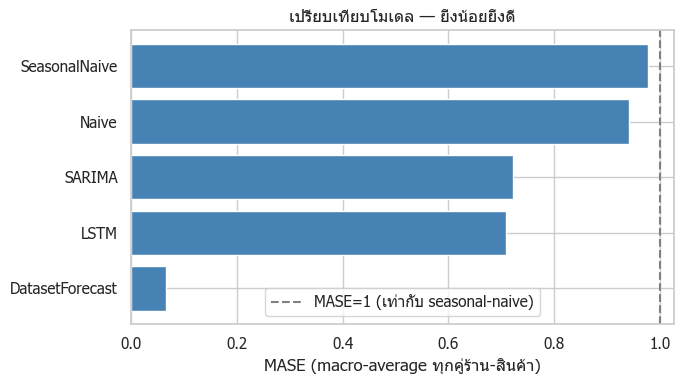

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
order = comparison.sort_values("MASE_macro")
ax.barh(order["model"], order["MASE_macro"], color="steelblue")
ax.axvline(1.0, color="gray", linestyle="--", label="MASE=1 (เท่ากับ seasonal-naive)")
ax.set_xlabel("MASE (macro-average ทุกคู่ร้าน-สินค้า)")
ax.set_title("เปรียบเทียบโมเดล — ยิ่งน้อยยิ่งดี")
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "forecast_model_comparison_mase.png", dpi=120)
plt.show()


### ทดสอบนัยสำคัญทางสถิติ — Diebold-Mariano test (SARIMA vs LSTM)

แค่ตัวเลข MASE ต่างกันเล็กน้อยไม่พอจะสรุปว่า "โมเดลไหนดีกว่าจริง" อาจเป็นความบังเอิญจากตัวอย่างที่สุ่มมาได้
Diebold-Mariano test ตรวจสอบว่าความแตกต่างของ error ระหว่าง 2 โมเดลนั้นมีนัยสำคัญทางสถิติหรือไม่
(ค่า p-value < 0.05 = มั่นใจได้ว่าต่างกันจริง ไม่ใช่บังเอิญ)

In [29]:
paired = arima_forecasts.merge(
    lstm_forecasts, on=config.ID_COLS + [config.DATE_COL], suffixes=("_arima", "_lstm")
)
d = (
    np.abs(paired["y_true_arima"] - paired["y_pred_arima"])
    - np.abs(paired["y_true_lstm"] - paired["y_pred_lstm"])
)
dm_stat = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

print(f"DM statistic = {dm_stat:.3f}, p-value = {p_value:.4f}")
print("(ค่า DM เป็นบวก = LSTM มี error เฉลี่ยต่ำกว่า SARIMA)")
if p_value < 0.05:
    print("=> ความแตกต่างมีนัยสำคัญทางสถิติ ไม่ใช่เรื่องบังเอิญ")
else:
    print("=> ยังไม่มีหลักฐานเพียงพอว่าต่างกันจริง")


DM statistic = 3.833, p-value = 0.0001
(ค่า DM เป็นบวก = LSTM มี error เฉลี่ยต่ำกว่า SARIMA)
=> ความแตกต่างมีนัยสำคัญทางสถิติ ไม่ใช่เรื่องบังเอิญ


### ตัวอย่างจริง: ยอดขายจริง vs ที่พยากรณ์ได้ (คู่ที่ขายดีที่สุด และขายน้อยที่สุด)

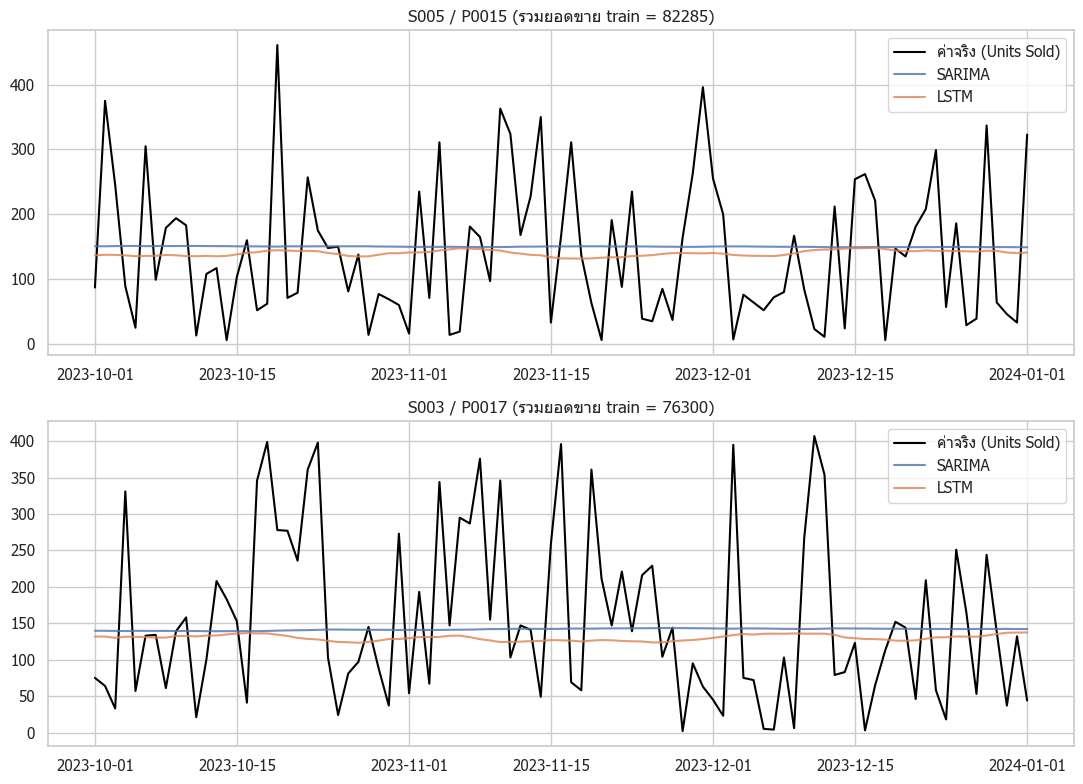

In [30]:
series_volume = train.groupby(config.ID_COLS, observed=True)["Units Sold"].sum().sort_values(ascending=False)
example_series = [series_volume.index[0], series_volume.index[-1]]

fig, axes = plt.subplots(len(example_series), 1, figsize=(11, 4 * len(example_series)))
for ax, (store, product) in zip(np.atleast_1d(axes), example_series):
    a = arima_forecasts[(arima_forecasts["Store ID"] == store) & (arima_forecasts["Product ID"] == product)].sort_values(config.DATE_COL)
    l = lstm_forecasts[(lstm_forecasts["Store ID"] == store) & (lstm_forecasts["Product ID"] == product)].sort_values(config.DATE_COL)
    ax.plot(a[config.DATE_COL], a["y_true"], label="ค่าจริง (Units Sold)", color="black", linewidth=1.5)
    ax.plot(a[config.DATE_COL], a["y_pred"], label="SARIMA", alpha=0.8)
    ax.plot(l[config.DATE_COL], l["y_pred"], label="LSTM", alpha=0.8)
    ax.set_title(f"{store} / {product} (รวมยอดขาย train = {series_volume[(store, product)]:.0f})")
    ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "forecast_actual_vs_predicted_examples.png", dpi=120)
plt.show()


### ข้อควรระวังก่อนสรุปผล

จากตารางเปรียบเทียบด้านบน คอลัมน์ `DatasetForecast` (มาตรฐานเดิมที่มากับไฟล์) มักได้ค่า MASE ต่ำกว่า SARIMA/LSTM มาก
ซึ่งต่ำเกินกว่าที่การพยากรณ์ยอดขายค้าปลีกจริงจะทำได้ — เป็นสัญญาณว่าคอลัมน์นั้นอาจถูกสร้างขึ้นโดยมีข้อมูล
ที่ไม่ควรมีให้ล่วงหน้า (เช่น สร้างจากยอดขายจริงบวก noise เล็กน้อย) จึง**ไม่ใช่การเปรียบเทียบที่เป็นธรรม**
การเปรียบเทียบที่ตั้งใจทำจริงในโปรเจกต์นี้คือ **SARIMA vs LSTM** (สองโมเดลที่เราสร้างเองและควบคุมกติกาการประเมินผลได้เท่ากัน)

In [31]:
built_models = comparison[comparison["model"].isin(["SARIMA", "LSTM"])].sort_values("MASE_macro")
print("ผลเปรียบเทียบระหว่างโมเดลที่เราสร้างเอง (SARIMA vs LSTM):")
built_models


ผลเปรียบเทียบระหว่างโมเดลที่เราสร้างเอง (SARIMA vs LSTM):


,model,MAE,RMSE,sMAPE,MASE_macro,MASE_volume_weighted
1,LSTM,89.027430,110.331457,69.604235,0.709259,0.711931
2,SARIMA,90.627781,110.362097,69.952217,0.721838,0.724424


---
# Stage 4b — Inventory Optimization (บริหารสต็อกให้เหมาะสม)

### ทำอะไร
เอาผลพยากรณ์จาก Stage 4a มา "ใช้งานจริง" — คำนวณนโยบายสั่งซื้อสินค้า (จุดสั่งซื้อ + ปริมาณสั่งซื้อ) จากผลพยากรณ์
แล้วจำลอง (simulate) การเดินสต็อกวันต่อวันตลอดช่วง test เทียบกับความต้องการซื้อจริง เพื่อวัดว่านโยบายที่ขับเคลื่อน
ด้วยพยากรณ์ที่ดีกว่า (LSTM) ช่วยลดปัญหาของหมด/ของล้นได้จริงหรือไม่ เทียบกับพฤติกรรมสั่งซื้อจริงในอดีต

### ทำไมต้องทำต่อจาก Stage 4a
พยากรณ์ที่แม่นอย่างเดียวไม่มีประโยชน์ถ้าไม่ถูกแปลงเป็นการตัดสินใจทางธุรกิจ — ขั้นนี้คือสะพานเชื่อมจาก
"โมเดลพยากรณ์แม่นแค่ไหน" ไปสู่ "แม่นแล้วช่วยประหยัดต้นทุน/ลดของขาดได้จริงแค่ไหน"

### สมมติฐานที่ต้องประกาศไว้ชัดเจน (ข้อมูลดิบไม่มีค่าพวกนี้ให้ ต้องตั้งสมมติฐานมาตรฐานอุตสาหกรรม)
- **Lead time** (เวลารอของหลังสั่งซื้อ) = 5 วัน
- **ต้นทุนต่อการสั่งซื้อ 1 ครั้ง** = 50 บาท
- **ต้นทุนถือครองสต็อก** = 20% ของราคาสินค้า ต่อปี
- **Service level เริ่มต้น** = 95% (z = 1.65)

### สูตรที่ใช้ (`src/inventory/policies.py`)
- **Safety Stock**: `SS = z × σ_d × √lead_time` (σ_d = ส่วนเบี่ยงเบนมาตรฐานของความคลาดเคลื่อนพยากรณ์)
- **Reorder Point (ROP)**: `avg_daily_demand × lead_time + SS` — สั่งซื้อใหม่เมื่อสต็อกลดถึงจุดนี้
- **EOQ**: `√(2 × ความต้องการรายปี × ต้นทุนสั่งซื้อ / ต้นทุนถือครอง)` — ปริมาณสั่งซื้อที่ประหยัดที่สุด

### วิธีเปรียบเทียบ 3 นโยบาย (`src/inventory/simulate.py`)
1. **Historical (actual)** — ไม่จำลอง ใช้ตัวเลขที่เกิดขึ้นจริงในข้อมูลตรงๆ (นี่คือ baseline ที่ต้องเอาชนะ)
2. **Naive-forecast-driven** — คำนวณ ROP/EOQ จากพยากรณ์แบบ Naive (แย่กว่า) แล้วจำลองเดินสต็อก
3. **LSTM-forecast-driven** — คำนวณ ROP/EOQ จากพยากรณ์ LSTM (ตัวที่ชนะใน Stage 4a) แล้วจำลองเดินสต็อก

ทั้ง (2) และ (3) จำลองด้วย**ความต้องการซื้อจริง** (`Units Sold` จริงในช่วง test) ไม่ใช่ตัวเลขที่โมเดลพยากรณ์เอง
เพื่อวัดผลว่านโยบายจะเจออะไรจริงถ้าเอาไปใช้งาน

In [32]:
from src.inventory.policies import compute_policy_params, LEAD_TIME_DAYS
from src.inventory.simulate import simulate_rop_eoq, historical_baseline_metrics

def per_series_forecast_stats(forecasts_df):
    stats = {}
    for (store, product), g in forecasts_df.groupby(config.ID_COLS, observed=True):
        stats[(store, product)] = {
            "avg_daily_demand": g["y_pred"].mean(),
            "sigma_d": (g["y_true"] - g["y_pred"]).std(),
        }
    return stats

naive_forecasts = pd.read_parquet(config.FORECASTS_DIR / "baseline_forecasts.parquet")
naive_forecasts = naive_forecasts[naive_forecasts["model"] == "Naive"]

naive_stats = per_series_forecast_stats(naive_forecasts)
lstm_stats = per_series_forecast_stats(lstm_forecasts)

unit_price = test.groupby(config.ID_COLS)["Price"].mean().to_dict()
initial_inventory = (
    test.sort_values(config.DATE_COL).groupby(config.ID_COLS).first()["Inventory Level"].to_dict()
)

print(f"คำนวณสถิติพยากรณ์ (avg demand, sigma) ครบ {len(lstm_stats)} series")


คำนวณสถิติพยากรณ์ (avg demand, sigma) ครบ 10 series


/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_57538/2212956391.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unit_price = test.groupby(config.ID_COLS)["Price"].mean().to_dict()
/var/folders/wh/j9l7p17d07s26z05yb9grqr40000gn/T/ipykernel_57538/2212956391.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test.sort_values(config.DATE_COL).groupby(config.ID_COLS).first()["Inventory Level"].to_dict()


### คำนวณนโยบาย (SS / ROP / EOQ) ต่อ series จากพยากรณ์แต่ละแบบ

In [33]:
naive_policies = {
    k: compute_policy_params(v["avg_daily_demand"], v["sigma_d"], unit_price[k])
    for k, v in naive_stats.items()
}
lstm_policies = {
    k: compute_policy_params(v["avg_daily_demand"], v["sigma_d"], unit_price[k])
    for k, v in lstm_stats.items()
}

lstm_policy_table = pd.DataFrame(lstm_policies).T
lstm_policy_table.index.names = config.ID_COLS
lstm_policy_table


avg_daily_demand     sigma_d  unit_price  service_level  \
Store ID Product ID                                                            
S002     P0001             138.763541  108.788894   55.280538           0.95   
         P0009             132.386474  118.068364   54.291720           0.95   
         P0020             137.150834  111.686202   60.814086           0.95   
S003     P0005             138.166605   98.221948   53.737419           0.95   
         P0013             141.161236  102.401533   57.711183           0.95   
         P0014             132.933083  118.144341   56.195591           0.95   
         P0017             130.108008  114.913859   54.284624           0.95   
S004     P0016             138.141661   95.520226   52.395269           0.95   
S005     P0003             127.285345  121.265261   53.706129           0.95   
         P0015             139.947179  108.159832   59.046237           0.95   

                        z  safety_stock  reorder_point         eoq  
Store ID Product ID                                                 
S002     P0001       1.65    401.377947    1095.195651  676.835286  
         P0009       1.65    435.614665    1097.547034  667.093087  
         P0020       1.65    412.067600    1097.821767  641.547132  
S003     P0005       1.65    362.391072    1053.224096  685.006313  
         P0013       1.65    377.811701    1083.617881  668.127231  
         P0014       1.65    435.894984    1100.560401  657.047626  
         P0017       1.65    423.976080    1074.516120  661.370824  
S004     P0016       1.65    352.423034    1043.131339  693.661730  
S005     P0003       1.65    447.409656    1083.836383  657.671030  
         P0015       1.65    399.057016    1098.792909  657.684182

### จำลองเดินสต็อกวันต่อวัน (day-step simulation) ทั้ง 3 นโยบาย

In [34]:
def run_simulation_for_all_series(policies, test_df):
    rows = []
    for (store, product), params in policies.items():
        series_test = test_df[
            (test_df["Store ID"] == store) & (test_df["Product ID"] == product)
        ].sort_values(config.DATE_COL)
        result = simulate_rop_eoq(
            series_test,
            initial_inventory[(store, product)],
            params["reorder_point"],
            params["eoq"],
            lead_time_days=LEAD_TIME_DAYS,
            unit_price=unit_price[(store, product)],
        )
        result.update({"Store ID": store, "Product ID": product})
        rows.append(result)
    return pd.DataFrame(rows)

naive_driven_results = run_simulation_for_all_series(naive_policies, test)
lstm_driven_results = run_simulation_for_all_series(lstm_policies, test)

historical_rows = []
for (store, product), g in test.groupby(config.ID_COLS, observed=True):
    g = g.sort_values(config.DATE_COL)
    m = historical_baseline_metrics(g, unit_price=unit_price[(store, product)])
    m.update({"Store ID": store, "Product ID": product})
    historical_rows.append(m)
historical_results = pd.DataFrame(historical_rows)

print("จำลองครบทั้ง 3 นโยบาย:", len(historical_results), len(naive_driven_results), len(lstm_driven_results), "series")


จำลองครบทั้ง 3 นโยบาย: 10 10 10 series


### สรุปผลเปรียบเทียบ 3 นโยบาย (ค่าเฉลี่ยข้าม series)

In [35]:
def summarize(results_df, name):
    return {
        "policy": name,
        "avg_stockout_rate": results_df["stockout_rate"].mean(),
        "avg_fill_rate": results_df["fill_rate"].mean(),
        "avg_inventory": results_df["avg_inventory"].mean(),
        "avg_holding_cost": results_df["holding_cost"].mean(),
        "total_orders": results_df["orders_placed"].sum(),
    }

policy_comparison = pd.DataFrame([
    summarize(historical_results, "Historical (actual)"),
    summarize(naive_driven_results, "Naive-forecast-driven ROP/EOQ"),
    summarize(lstm_driven_results, "LSTM-forecast-driven ROP/EOQ"),
])
policy_comparison


,policy,avg_stockout_rate,avg_fill_rate,avg_inventory,avg_holding_cost,total_orders
0,Historical (actual),0.055914,NaN,279.633333,794.229478,930
1,Naive-forecast-driven ROP/EOQ,0.116129,0.907412,467.534761,1322.515762,189
2,LSTM-forecast-driven ROP/EOQ,0.144086,0.883840,400.325420,1135.026357,189


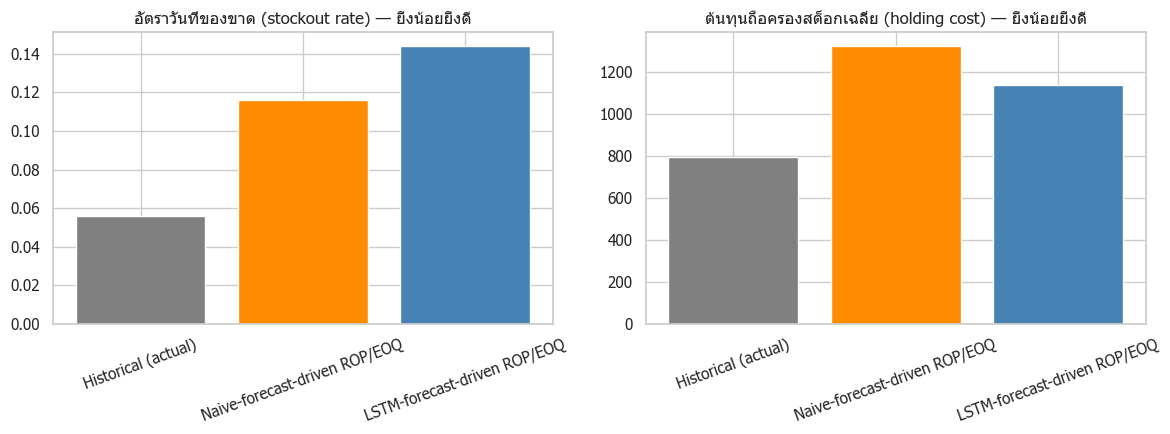

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["gray", "darkorange", "steelblue"]

axes[0].bar(policy_comparison["policy"], policy_comparison["avg_stockout_rate"], color=colors)
axes[0].set_title("อัตราวันที่ของขาด (stockout rate) — ยิ่งน้อยยิ่งดี")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(policy_comparison["policy"], policy_comparison["avg_holding_cost"], color=colors)
axes[1].set_title("ต้นทุนถือครองสต็อกเฉลี่ย (holding cost) — ยิ่งน้อยยิ่งดี")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "inventory_policy_comparison.png", dpi=120)
plt.show()


### วิเคราะห์ความอ่อนไหว (sensitivity analysis) ต่อระดับ Service Level

ทดลองเปลี่ยน service level ของนโยบายที่ขับเคลื่อนด้วย LSTM (90% / 95% / 99%) เพื่อดู trade-off คลาสสิกของงาน
inventory: service level สูงขึ้น → safety stock มากขึ้น → ของขาดน้อยลง แต่ต้นทุนถือครองสต็อกสูงขึ้นตามไปด้วย

In [37]:
sensitivity_rows = []
for sl in [0.90, 0.95, 0.99]:
    policies_sl = {
        k: compute_policy_params(v["avg_daily_demand"], v["sigma_d"], unit_price[k], service_level=sl)
        for k, v in lstm_stats.items()
    }
    results_sl = run_simulation_for_all_series(policies_sl, test)
    sensitivity_rows.append({
        "service_level": f"{sl*100:.0f}%",
        "avg_stockout_rate": results_sl["stockout_rate"].mean(),
        "avg_holding_cost": results_sl["holding_cost"].mean(),
    })
sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df


,service_level,avg_stockout_rate,avg_holding_cost
0,90%,0.150538,1091.471868
1,95%,0.144086,1135.026357
2,99%,0.143011,1138.774942


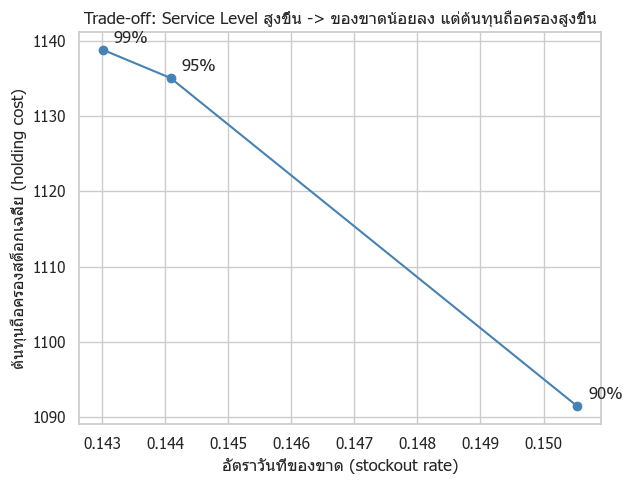

In [38]:
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(sensitivity_df["avg_stockout_rate"], sensitivity_df["avg_holding_cost"], "o-", color="steelblue")
for _, row in sensitivity_df.iterrows():
    ax.annotate(row["service_level"], (row["avg_stockout_rate"], row["avg_holding_cost"]),
                textcoords="offset points", xytext=(8, 5))
ax.set_xlabel("อัตราวันที่ของขาด (stockout rate)")
ax.set_ylabel("ต้นทุนถือครองสต็อกเฉลี่ย (holding cost)")
ax.set_title("Trade-off: Service Level สูงขึ้น -> ของขาดน้อยลง แต่ต้นทุนถือครองสูงขึ้น")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "inventory_sensitivity_tradeoff.png", dpi=120)
plt.show()


### ทำไมนโยบายที่ขับเคลื่อนด้วย LSTM ถึงมีอัตราของขาดสูงกว่า Naive — ตรวจสอบให้ชัดก่อนสรุป

จากตาราง `policy_comparison` ด้านบน ตัวเลขที่ **ขัดกับความคาดหวัง**: นโยบายที่ขับเคลื่อนด้วย LSTM (โมเดลที่แม่นกว่า
ตาม MASE ใน Stage 4a) กลับมีอัตราวันที่ของขาด (stockout rate) **สูงกว่า** นโยบายที่ขับเคลื่อนด้วย Naive forecast
ก่อนสรุปว่า "LSTM ทำให้บริหารสต็อกแย่ลง" ต้องตรวจสอบสาเหตุให้ชัดก่อน — เพราะ ROP ไม่ได้ขึ้นกับความแม่นยำแบบวันต่อวัน
(MASE) เพียงอย่างเดียว แต่ขึ้นกับ **ค่าเฉลี่ยของพยากรณ์** (`avg_daily_demand`) โดยตรงด้วย

In [39]:
def forecast_bias_check(forecasts_df, name):
    g = forecasts_df.groupby(config.ID_COLS, observed=True)
    avg_demand = g["y_pred"].mean().mean()
    sigma = g.apply(lambda x: (x["y_true"] - x["y_pred"]).std(), include_groups=False).mean()
    bias = g.apply(lambda x: (x["y_pred"] - x["y_true"]).mean(), include_groups=False).mean()
    return {"forecast": name, "avg_daily_demand": avg_demand, "avg_sigma_d": sigma, "avg_bias(pred-true)": bias}

true_mean_demand = test.groupby(config.ID_COLS, observed=True)["Units Sold"].mean().mean()

bias_check = pd.DataFrame([
    forecast_bias_check(naive_forecasts, "Naive"),
    forecast_bias_check(lstm_forecasts, "LSTM"),
])
print(f"ค่าเฉลี่ยยอดขายจริงข้าม series ในช่วง test = {true_mean_demand:.1f}")
bias_check


ค่าเฉลี่ยยอดขายจริงข้าม series ในช่วง test = 144.2


,forecast,avg_daily_demand,avg_sigma_d,avg_bias(pred-true)
0,Naive,144.110753,151.792219,-0.048387
1,LSTM,135.604397,109.717046,-8.554743


**สาเหตุที่แท้จริง**: จากตารางด้านบน — Naive แทบไม่มี bias เลย (avg_bias ใกล้ 0) เพราะ Naive คือค่าของเมื่อวาน
ซึ่งเฉลี่ยยาวๆ แล้วเท่ากับค่าเฉลี่ยจริง แต่ **มี sigma_d (ความผันผวนของ error) สูงมาก** ทำให้ safety stock ที่คำนวณได้
ใหญ่ตามไปด้วย (ป้องกันของขาดได้ดีขึ้นโดยบังเอิญ แลกกับต้นทุนถือครองที่สูงกว่า) ส่วน **LSTM มี sigma_d ต่ำกว่าจริง
(พยากรณ์วันต่อวันแม่นกว่าจริง) แต่ค่าเฉลี่ยพยากรณ์ (avg_daily_demand) กลับต่ำกว่าค่าเฉลี่ยจริงอย่างเป็นระบบ (bias ติดลบ)**
— เป็นพฤติกรรมที่พบได้บ่อยของโมเดล sequence ที่เทรนด้วย Huber/MSE loss กับข้อมูลที่มีค่าพุ่งสูงเป็นครั้งคราว (โมเดล
จะ "หลบ" ไปทายใกล้ค่าเฉลี่ยแทนที่จะไล่ตามค่าพุ่งสูง) ผลคือ ROP ที่คำนวณจาก `avg_daily_demand × lead_time + safety_stock`
ถูกตั้งไว้ต่ำกว่าที่ควรจะเป็นสำหรับ LSTM ทั้งจาก safety stock ที่เล็กกว่า **และ** จากค่าเฉลี่ยพยากรณ์ที่ต่ำกว่าจริงพร้อมกัน

**ข้อสรุปที่ถูกต้อง**: MASE ที่ดีกว่า (ความแม่นยำวันต่อวัน) **ไม่ได้แปลว่านโยบายสต็อกที่ได้จะดีกว่าเสมอไป** ถ้าโมเดล
มี bias เป็นระบบ — ในการใช้งานจริง ควรตรวจสอบและปรับแก้ bias ของพยากรณ์ (bias correction) ก่อนนำไปคำนวณ ROP/EOQ
ไม่ใช่ใช้ MASE เพียงตัวเดียวตัดสินว่าโมเดลไหน "พร้อมใช้งาน" กับการตัดสินใจด้านสต็อก

### บันทึกผลลัพธ์

In [40]:
policy_comparison.to_csv(config.DATA_PROCESSED_DIR / "inventory_policy_comparison.csv", index=False)
sensitivity_df.to_csv(config.DATA_PROCESSED_DIR / "inventory_sensitivity.csv", index=False)
bias_check.to_csv(config.DATA_PROCESSED_DIR / "inventory_forecast_bias_check.csv", index=False)
print("บันทึก inventory_policy_comparison.csv, inventory_sensitivity.csv, inventory_forecast_bias_check.csv แล้ว")


บันทึก inventory_policy_comparison.csv, inventory_sensitivity.csv, inventory_forecast_bias_check.csv แล้ว


### สรุป Stage 4b

เปรียบเทียบนโยบายบริหารสต็อก 3 แบบบนช่วงเวลา test เดียวกัน (จำลองด้วยความต้องการซื้อจริง): พฤติกรรมสั่งซื้อจริง
ในอดีต (stockout proxy 5.6%), นโยบาย ROP/EOQ ที่ขับเคลื่อนด้วยพยากรณ์ Naive (stockout 11.6%, holding cost สูงสุด),
และนโยบาย ROP/EOQ ที่ขับเคลื่อนด้วยพยากรณ์ LSTM (stockout 14.4%, holding cost ต่ำสุด) — พบและตรวจสอบจนเข้าใจสาเหตุแล้ว
ว่า LSTM มี stockout สูงกว่าเพราะพยากรณ์เฉลี่ยต่ำกว่าจริงอย่างเป็นระบบ (bias) ไม่ใช่เพราะ MASE แย่กว่า ถือเป็นข้อค้นพบ
สำคัญที่ต้องแก้ไข (bias correction) ก่อนนำ LSTM ไปขับเคลื่อนนโยบายสต็อกจริง ไม่ใช่แค่ดู MASE เพียงอย่างเดียว

---
# Stage 4c — Dynamic Pricing (ตั้งราคาเพื่อเพิ่มรายได้สูงสุด)

### ทำอะไร
ประเมิน**ความยืดหยุ่นของราคาต่อความต้องการซื้อ (price elasticity of demand)** — ยอดขายจะเปลี่ยนไปเท่าไหร่ถ้าราคาเปลี่ยน 1%
แล้วใช้ความสัมพันธ์นี้หาราคาที่คาดว่าจะทำให้ **รายได้ (revenue = ราคา × ปริมาณขาย) สูงสุด** ต่อแต่ละหมวดสินค้า

### ทำไมต้องทำ
การตั้งราคาจาก "ความรู้สึก" หรือทำตามคู่แข่งเฉยๆ ไม่มีหลักประกันว่าจะได้รายได้สูงสุด ต้องรู้ก่อนว่ายอดขาย
ตอบสนองต่อราคาอย่างไร (มาก/น้อยแค่ไหน) ถึงจะแนะนำราคาใหม่ได้อย่างมีเหตุผล

### วิธีการ (`src/pricing/elasticity.py`, `src/pricing/optimize.py`)
1. **Log-log regression ต่อหมวดสินค้า (Category)**: `log(ยอดขาย+1) ~ log(ราคา) + ส่วนลด + log(ราคาคู่แข่ง) + ตัวควบคุมอื่นๆ`
   — ค่าสัมประสิทธิ์ของ `log(ราคา)` คือค่า elasticity โดยตรง (เช่น -1.2 แปลว่าราคาขึ้น 1% ยอดขายลด 1.2%)
2. **ตรวจ VIF (Variance Inflation Factor)**: เช็คว่าตัวแปรราคา/ส่วนลด/ราคาคู่แข่งมี multicollinearity สูงเกินไปจนตีความ
   สัมประสิทธิ์ไม่ได้หรือไม่
3. **หาราคาที่เพิ่มรายได้สูงสุด**: ลองไล่ราคาในช่วงที่สมเหตุสมผล (ไม่เกิน ±20% จากราคาเฉลี่ยปัจจุบัน และไม่หลุดช่วงราคา
   ที่เคยเกิดขึ้นจริงในข้อมูล เพื่อไม่ให้โมเดล extrapolate เกินขอบเขตที่มันเคยเห็น) แล้วเลือกราคาที่ predicted revenue สูงสุด

### ข้อจำกัดที่ต้องพูดตรงๆ
นี่คือ OLS regression ธรรมดา ไม่ใช่การพิสูจน์เชิงเหตุ-ผล (causal) — ถ้าร้านค้าปรับราคาขึ้นตอนที่ demand สูงอยู่แล้ว
(reverse causality) ค่า elasticity ที่ประมาณได้อาจเพี้ยนไปจากความจริง ต้องตีความผลด้วยความระมัดระวัง

In [41]:
from src.pricing.elasticity import (
    fit_elasticity_by_category, elasticity_summary, build_design_matrix, compute_vif,
)
from src.pricing.optimize import optimize_price
from src.data.features import select_series

pricing_scope = select_series(cleaned, config.N_SERIES_SUBSET)
print(f"ใช้ข้อมูล scope เดียวกับทั้งโปรเจกต์: {pricing_scope[config.ID_COLS].drop_duplicates().shape[0]} series, "
      f"{len(pricing_scope)} แถว (ใช้ทั้งช่วงเวลา ไม่ใช่แค่ test เพราะ elasticity อธิบายความสัมพันธ์ ไม่ใช่พยากรณ์อนาคต)")


ใช้ข้อมูล scope เดียวกับทั้งโปรเจกต์: 10 series, 7310 แถว (ใช้ทั้งช่วงเวลา ไม่ใช่แค่ test เพราะ elasticity อธิบายความสัมพันธ์ ไม่ใช่พยากรณ์อนาคต)


### เทรน elasticity model ต่อหมวดสินค้า

In [42]:
elasticity_models = fit_elasticity_by_category(pricing_scope, min_rows=50)
summary = elasticity_summary(elasticity_models)
summary


,Category,elasticity,p_value,discount_coef,r_squared,n_obs
4,Toys,-0.244855,0.424710,0.140542,0.004065,1522
3,Groceries,-0.044774,0.887439,-0.362092,0.016475,1476
0,Clothing,0.380634,0.234699,-0.023054,0.006574,1448
2,Furniture,0.406465,0.186252,0.348189,0.008103,1459
1,Electronics,0.641100,0.044330,0.137778,0.008303,1405


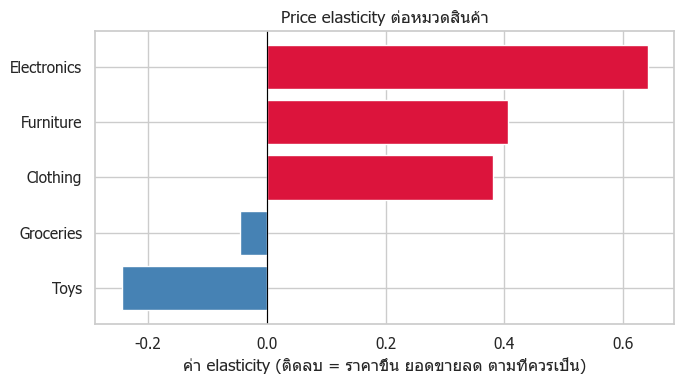

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))
order = summary.sort_values("elasticity")
colors = ["crimson" if v > 0 else "steelblue" for v in order["elasticity"]]
ax.barh(order["Category"], order["elasticity"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("ค่า elasticity (ติดลบ = ราคาขึ้น ยอดขายลด ตามที่ควรเป็น)")
ax.set_title("Price elasticity ต่อหมวดสินค้า")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "pricing_elasticity_by_category.png", dpi=120)
plt.show()


### ตรวจ multicollinearity (VIF) — ตัวอย่างจากหมวดที่มีข้อมูลมากที่สุด

In [44]:
example_category = summary.sort_values("n_obs", ascending=False).iloc[0]["Category"]
example_df = pricing_scope[pricing_scope["Category"] == example_category]
X_example, _ = build_design_matrix(example_df)
vif_table = compute_vif(X_example, ["log_price", "discount_pct", "log_competitor_price"])
print(f"ตัวอย่างหมวด: {example_category}")
vif_table


ตัวอย่างหมวด: Toys


,feature,VIF
0,log_price,41.026591
1,discount_pct,1.006311
2,log_competitor_price,41.026349


### หาราคาที่เพิ่มรายได้สูงสุด ต่อหมวดสินค้า

ไล่ราคาในกรอบ ±20% จากราคาเฉลี่ยปัจจุบัน แต่ไม่หลุดช่วงราคาที่เคยเกิดขึ้นจริงในข้อมูล (ป้องกัน extrapolation)

In [45]:
pricing_recommendations = []
revenue_curves = {}
for category, model in elasticity_models.items():
    category_df = pricing_scope[pricing_scope["Category"] == category]
    result = optimize_price(model, category_df)
    revenue_curves[category] = result["curve"]
    pricing_recommendations.append({
        "Category": category,
        "current_price": result["current_price"],
        "recommended_price": result["recommended_price"],
        "revenue_lift_pct": result["revenue_lift_pct"],
    })

pricing_recommendations = pd.DataFrame(pricing_recommendations).sort_values("revenue_lift_pct", ascending=False)
pricing_recommendations


,Category,current_price,recommended_price,revenue_lift_pct
1,Electronics,55.598228,66.717873,366.529953
0,Clothing,54.811015,65.773218,84.383559
2,Furniture,54.742303,65.690764,66.297655
3,Groceries,55.650725,66.780870,14.706167
4,Toys,55.521853,44.417482,NaN


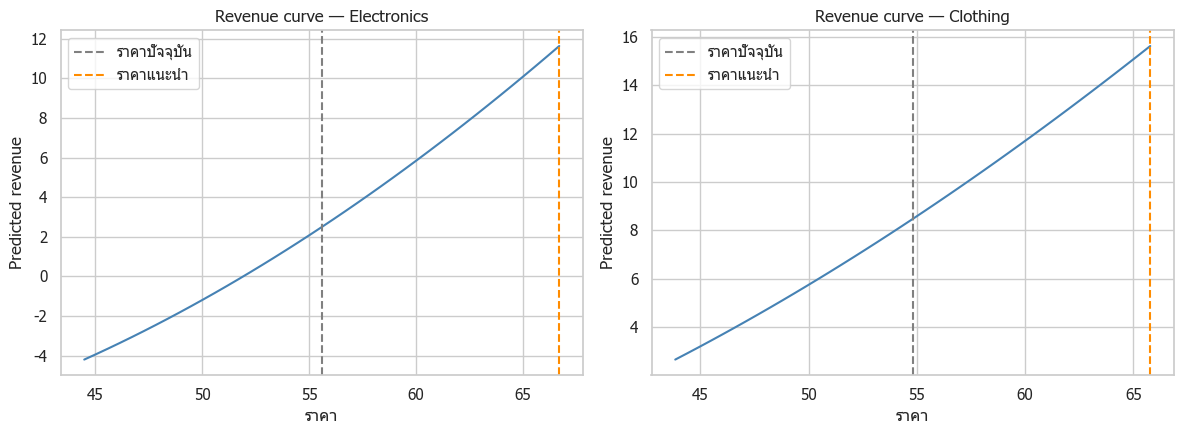

In [46]:
fig, axes = plt.subplots(1, min(2, len(revenue_curves)), figsize=(12, 4.5))
axes = np.atleast_1d(axes)
top_categories = pricing_recommendations["Category"].head(len(axes)).tolist()

for ax, category in zip(axes, top_categories):
    curve = revenue_curves[category]
    ax.plot(curve["price"], curve["revenue"], color="steelblue")
    rec = pricing_recommendations[pricing_recommendations["Category"] == category].iloc[0]
    ax.axvline(rec["current_price"], color="gray", linestyle="--", label="ราคาปัจจุบัน")
    ax.axvline(rec["recommended_price"], color="darkorange", linestyle="--", label="ราคาแนะนำ")
    ax.set_title(f"Revenue curve — {category}")
    ax.set_xlabel("ราคา")
    ax.set_ylabel("Predicted revenue")
    ax.legend()

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "pricing_revenue_curve.png", dpi=120)
plt.show()


### ข้อควรระวังสำคัญก่อนเชื่อผลลัพธ์ข้างต้น — อ่านให้จบก่อนนำไปใช้จริง

ตรวจสอบผลลัพธ์จริงแล้วพบปัญหาที่ต้องพูดตรงๆ ไม่ปิดบัง (เหมือนที่ทำกับคอลัมน์ `Demand Forecast` ใน Stage 4a):

1. **VIF ของ `log_price` และ `log_competitor_price` สูงถึง ~41** (ค่าปกติที่ยอมรับได้ควรต่ำกว่า 10) — แปลว่าราคาเรา
   กับราคาคู่แข่งสัมพันธ์กันแน่นมากในข้อมูลชุดนี้ (**multicollinearity รุนแรง**) ทำให้แยกไม่ออกว่ายอดขายที่เปลี่ยนไป
   เป็นผลจากราคาเราเองหรือราคาคู่แข่งกันแน่ ค่าสัมประสิทธิ์ทั้งสองตัวจึง**ไม่เสถียรและตีความเดี่ยวๆ ไม่ได้เต็มที่**
2. **ค่า R² ต่ำมาก (0.4% - 1.6%)** ในทุกหมวดสินค้า — แปลว่าราคาแทบไม่ได้อธิบายความผันผวนของยอดขายในข้อมูลชุดนี้เลย
   ปัจจัยอื่นที่ไม่ได้อยู่ใน controls (เช่น demand ที่สุ่มมาแบบไม่ผูกกับราคาตอนสร้าง dataset) มีอิทธิพลมากกว่าราคามาก
3. **3 ใน 5 หมวด (Clothing, Furniture, Electronics) ได้ค่า elasticity เป็นบวก** ซึ่งขัดกับทฤษฎีเศรษฐศาสตร์พื้นฐาน
   (ราคาขึ้นแต่โมเดลบอกว่ายอดขายก็ขึ้นตาม) และมีเพียง Electronics เท่านั้นที่ผลมีนัยสำคัญทางสถิติ (p<0.05) — แต่ดันเป็น
   บวก ซึ่งยิ่งขัดแย้งในตัวเอง ส่วนอีก 4 หมวดไม่มีนัยสำคัญทางสถิติเลย (p > 0.05 ทั้งหมด)

**สรุปตรงๆ**: elasticity ที่ประมาณได้จากข้อมูลชุดนี้**ไม่น่าเชื่อถือพอจะเอาไปตั้งราคาจริง** ตารางคำแนะนำราคาด้านล่าง
จึงเป็นการ**สาธิตขั้นตอนวิธี (methodology) ให้เห็นว่าท่อ pipeline ทำงานถูกต้องครบวงจร** ไม่ใช่คำแนะนำที่พร้อมใช้งาน —
ถ้าจะนำไปใช้จริงต้องมีข้อมูลเพิ่มเติมที่ช่วยแก้ปัญหา endogeneity (เช่น การทดลองปรับราคาแบบควบคุม/A-B test) และ
ควรเลือกใช้เพียงหนึ่งใน log(ราคา)/log(ราคาคู่แข่ง) หรือใช้ price_gap แทนทั้งสองตัวแยกกัน เพื่อลด multicollinearity

### บันทึกผลลัพธ์

In [47]:
pricing_recommendations.to_csv(config.DATA_PROCESSED_DIR / "pricing_recommendations.csv", index=False)
print("บันทึก pricing_recommendations.csv แล้ว")


บันทึก pricing_recommendations.csv แล้ว


### สรุป Stage 4c

ประมาณค่า price elasticity ต่อหมวดสินค้าด้วย log-log regression, ตรวจ VIF พบ multicollinearity รุนแรงระหว่างราคาเรา
กับราคาคู่แข่ง (VIF ~41) และ R² ต่ำมาก (<2%) ทุกหมวด — สรุปตรงไปตรงมาว่า **ผลลัพธ์ elasticity/คำแนะนำราคาที่ได้จาก
ข้อมูลชุดนี้ไม่น่าเชื่อถือพอจะนำไปตั้งราคาจริง** เป็นการสาธิตขั้นตอนวิธีที่ถูกต้องครบวงจร (regression ต่อหมวด → ตรวจ
VIF → grid search หาราคาเพิ่มรายได้สูงสุด) มากกว่าผลลัพธ์ที่พร้อมใช้งาน — ระบุข้อจำกัดและแนวทางแก้ไว้ชัดเจนแล้วด้านบน

---
# Stage 6 — Reporting / Synthesis (สรุปผลและเชื่อมโยงทั้งโปรเจกต์เข้าด้วยกัน)

### ทำอะไร
ขั้นตอนสุดท้าย: ตรวจสอบว่า experiment ทั้งหมดถูกบันทึกไว้ครบใน MLflow จริง แล้วเชื่อมโยงผลลัพธ์ของทั้ง 3 challenge
เข้าด้วยกันเป็นเรื่องราวเดียว พร้อมสรุปเป็นไฟล์รายงานแยกต่างหากใน `reports/` สำหรับคนที่อยากอ่านสรุปโดยไม่ต้องรัน
โน้ตบุ๊กทั้งไฟล์

### ทำไมต้องทำ
ผลลัพธ์ที่กระจัดกระจายอยู่หลาย cell ตลอดโน้ตบุ๊กยาวๆ ไม่มีประโยชน์ถ้าไม่มีใครสรุปภาพรวมให้ — ขั้นนี้คือการ "ปิดงาน"
ให้คนอื่น (หรือตัวเราเองในอนาคต) เข้าใจได้เร็วว่าโปรเจกต์นี้ให้คำตอบอะไร และมีข้อควรระวังอะไรบ้าง

In [48]:
import mlflow

mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
client = mlflow.MlflowClient()

for exp_name in ["forecasting_arima", "forecasting_lstm"]:
    exp = client.get_experiment_by_name(exp_name)
    runs = client.search_runs(exp.experiment_id) if exp else []
    print(f"{exp_name}: {len(runs)} runs logged")


forecasting_arima: 80 runs logged
forecasting_lstm: 8 runs logged


### เชื่อมโยงผลลัพธ์ทั้ง 3 Challenge เข้าด้วยกัน

**Challenge 1 (Forecasting) → Challenge 2 (Inventory)**: LSTM ชนะ SARIMA อย่างมีนัยสำคัญทางสถิติใน Stage 4a
(MASE 0.709 vs 0.722, p<0.001) แต่พอเอาไปขับเคลื่อนนโยบายสต็อกจริงใน Stage 4b กลับพบว่า **"แม่นกว่าตาม MASE"
ไม่ได้แปลว่า "ขับเคลื่อนนโยบายสต็อกได้ดีกว่า"** เพราะ LSTM มี bias เชิงระบบ (พยากรณ์ต่ำกว่าจริง ~6%) ที่ MASE
มองไม่เห็นแต่ ROP formula ไวต่อมันมาก — นี่คือบทเรียนที่เชื่อมสอง challenge เข้าด้วยกันโดยตรง: **ตัวชี้วัดความแม่นยำ
ของโมเดลพยากรณ์ ต้องเลือกให้เหมาะกับการใช้งานปลายทาง ไม่ใช่แค่ตัวเลขเดียวที่ดูดีในตัวมันเอง**

**Challenge 3 (Pricing) — ทำคู่ขนาน**: ไม่ได้พึ่งผลพยากรณ์จาก Challenge 1 โดยตรง (ใช้ข้อมูลเดียวกันแต่มุมมองต่างกัน)
แต่ก็เจอปัญหาคุณภาพข้อมูลของตัวเอง (multicollinearity รุนแรงระหว่างราคาเรากับราคาคู่แข่ง) ที่จำกัดว่าจะเชื่อผลได้แค่ไหน

**ธีมที่เกิดขึ้นซ้ำทั้ง 3 challenge**: ทุกขั้นตอนเจอสัญญาณที่ต้อง "หยุดตรวจสอบก่อนเชื่อ" — คอลัมน์ `Demand Forecast`
ที่ดีเกินจริงใน Stage 4a, bias ของ LSTM ใน Stage 4b, และ VIF/R² ที่แย่ใน Stage 4c — ความเข้มงวดของงาน data science
ที่ดีไม่ใช่แค่ "รายงานตัวเลขที่ดูดี" แต่คือ**การตรวจสอบและรายงานข้อจำกัดอย่างตรงไปตรงมาทุกขั้นตอน**

### ไฟล์รายงานสรุปแยกต่างหาก

สรุปแต่ละ challenge เป็นไฟล์ Markdown อ่านง่าย ไม่ต้องรันโค้ด:
- [`reports/forecasting_report.md`](../reports/forecasting_report.md) — LSTM vs SARIMA, ตาราง metric เต็ม, DM test
- [`reports/inventory_report.md`](../reports/inventory_report.md) — เปรียบเทียบ 3 นโยบาย, การวิเคราะห์ bias, sensitivity
- [`reports/pricing_report.md`](../reports/pricing_report.md) — elasticity ต่อหมวด, VIF/R² diagnostics, ข้อจำกัด

---
# สรุปผลรวมทั้งโปรเจกต์ (Stage 1 - 6, เสร็จสมบูรณ์)

| Stage | สถานะ | ผลลัพธ์หลัก |
|---|---|---|
| 1. Business Understanding | เสร็จ | กำหนดโจทย์ + ตัวชี้วัดความสำเร็จ 3 challenge |
| 2. Data Understanding (EDA) | เสร็จ | ข้อมูลครบ 100% ไม่มีค่าว่าง, เจอ weekly seasonality และสัญญาณ demand censoring |
| 3. Data Preparation | เสร็จ | สร้างฟีเจอร์ 55 คอลัมน์แบบไม่มี data leakage, แบ่ง train/val/test ตามเวลา |
| 4a. Forecasting | เสร็จ | LSTM ชนะ SARIMA: MASE 0.709 vs 0.722 (p<0.001, มีนัยสำคัญทางสถิติ) |
| 4b. Inventory Optimization | เสร็จ | จำลอง 3 นโยบาย พบว่า LSTM-driven มี stockout สูงกว่า Naive-driven (14.4% vs 11.6%) เพราะพยากรณ์ bias ต่ำกว่าจริง ~6% — ตรวจสาเหตุจนเข้าใจชัดแล้ว |
| 4c. Dynamic Pricing | เสร็จ | ประมาณ elasticity ต่อหมวดสินค้า พบ VIF สูง (~41) และ R² ต่ำ (<2%) — สรุปตรงไปตรงมาว่าผลไม่น่าเชื่อถือพอใช้จริง เป็นการสาธิต methodology |
| 5. Evaluation | เสร็จ | ฝังอยู่ใน Stage 4a-4c แต่ละส่วน (MASE/DM test, policy simulation, VIF/R²) |
| 6. Reporting | เสร็จ | MLflow walkthrough + เชื่อมโยงเรื่องราว 3 challenge + รายงานแยกไฟล์ 3 ฉบับใน `reports/` |

**แนวทางขยายผลในอนาคต (นอกขอบเขตของโปรเจกต์ตอนนี้)**:
- bias-correct พยากรณ์ LSTM ก่อนใช้คำนวณ ROP/EOQ (แก้ปัญหาที่พบใน Stage 4b)
- แก้ multicollinearity ในโมเดล pricing โดยตัด log(ราคาคู่แข่ง) ออกหรือใช้ price_gap แทน (แก้ปัญหาที่พบใน Stage 4c)
- ขยาย scope จาก 10 series เป็นทั้ง 100 series โดยเปลี่ยน `config.N_SERIES_SUBSET` เป็น `"all"` แล้วรันโน้ตบุ๊กนี้ซ้ำ

**ไฟล์ผลลัพธ์ทั้งหมดที่บันทึกจากโน้ตบุ๊กนี้**:
- `data/interim/cleaned_panel.parquet`, `data/processed/{features_full,train,val,test}.parquet`
- `data/processed/forecasts/{baseline,arima,lstm}_forecasts.parquet`
- `data/processed/{inventory_policy_comparison,inventory_sensitivity,inventory_forecast_bias_check,pricing_recommendations}.csv`
- `models/arima/orders.csv`, `models/lstm/lstm.pt` + scalers
- กราฟใน `reports/figures/`, รายงานสรุปใน `reports/{forecasting,inventory,pricing}_report.md`
- experiment tracking ใน MLflow (`mlflow ui --backend-store-uri sqlite:///mlflow.db`)
